# Climate Change Public Opinion Analysis using Machine Learning

# Table of Contents

Title

Table of Contents

Introduction

Problem Statement

Project Objective

Dataset Description

Import Libraries

Load Dataset

Basic Information

Check Missing Values

Data Preprocessing

Exploratory Data Analysis (EDA)

Likes Distribution

Comment Length Analysis

Sentiment Distribution

Trend Analysis

Feature Engineering

Machine Learning Model

Logistic Regression Model

Model Evaluation

Engagement Analysis

Insights and Findings

Conclusion

Future Improvements



# Introduction

Climate change is a major global issue, and people share their opinions about it on online platforms. Analyzing these opinions helps in understanding public perception. In this project, we analyze climate change comments from NASA using sentiment analysis to identify whether the opinions are positive, negative, or neutral.

## Problem Statement

It is difficult to manually analyze a large number of public comments related to climate change. The problem is to automatically classify these comments into positive, negative, or neutral sentiments using TextBlob and understand overall public opinion.

## Project Objective

The objective of this project is to analyze public opinion on climate change using NASA Facebook comments dataset.

This includes:

• Sentiment Analysis  
• Engagement Analysis  
• Trend Analysis  
• Machine Learning prediction  

This helps understand public perception of climate change.

# Dataset Description

The dataset contains public comments from NASA’s Climate Change Facebook page.

It includes:

• Date - Comment date  
• LikesCount - Number of likes  
• CommentsCount - Number of replies  
• Text - Comment content  

This dataset helps analyze public opinion on climate change.

#  Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from textblob import TextBlob

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#  Load Dataset

In [2]:
# upload dataset file to google colab
df = pd.read_csv('/content/climate_nasa.csv')

# Print first 5 entries of the dataset
df.head()

,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


**Observation**

We can see columns:

*   Date
*   LikesCount
*   CommentsCount
*   Text

This dataset contains public comments on climate change.

#  Basic Information

In [3]:
# Dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


**Observation**

This shows:

* Number of rows
* Missing values
* Data types

#  Check Missing Values

In [4]:
# Check missing values

df.isnull().sum()

,0
date,0
likesCount,0
profileName,0
commentsCount,278
text,18


**Observation**

Missing values can affect model performance.

We will remove them.

# Data Preprocessing

In [5]:
# Remove missing values/ Cleaning data

df = df.dropna()

df.shape

(242, 5)

**Observation**

Dataset is now clean.

# Exploratory Data Analysis (EDA)

1. Likes Distribution
2. Comment Length Analysis
3. Sentiment Distribution
4. Engagement Analysis

# 1. Likes Distribution

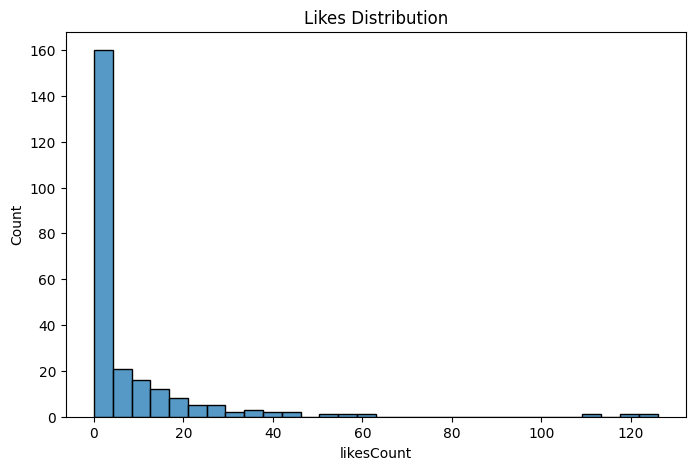

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['likesCount'], bins=30)

plt.title("Likes Distribution")

plt.show()

**Observation**

Most comments receive low likes.

Few comments receive high likes.

This shows engagement inequality.

#  2. Comment Length Analysis

In [7]:
# Create new feature

df['Comment_Length'] = df['text'].apply(len)

df.head()

,date,likesCount,profileName,commentsCount,text,Comment_Length
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...,108
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart...",128
5,2022-09-15T17:10:57.000Z,4,191055fb869d185092abf1405f0b2f4abe73bcaa9beb85...,1.0,Excellent example...very relatable to the Gen ...,104
7,2022-09-07T18:07:53.000Z,1,39c3ec5a079b6b1a62577a1d13d4e8f894c5525575b85d...,21.0,Has the Earth ever had a concentration of over...,56
9,2022-09-07T16:30:55.000Z,4,31fd4cfea1a56eb21ad6a86ce4ed94e6a15e654b3557bf...,8.0,Historical co2 data would make it an interesti...,53


**Comment Length vs Likes**

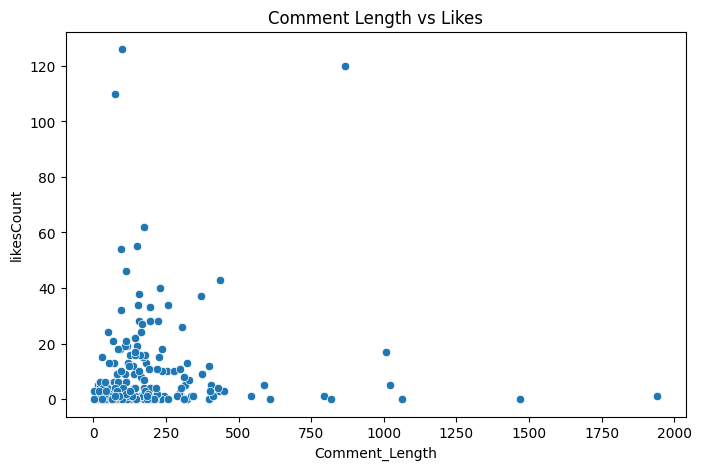

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Comment_Length', y='likesCount', data=df)

plt.title("Comment Length vs Likes")

plt.show()

**Observation:**

Longer comments tend to receive more likes.

**Comment Length Distribution**

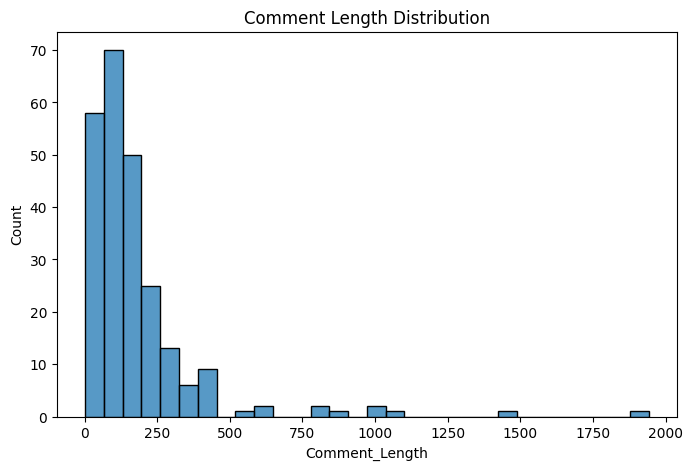

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Comment_Length'], bins=30)

plt.title("Comment Length Distribution")

plt.show()

**Observation**

Most comments are short.

Some are long detailed comments.

# 3. Sentiment Analysis using TextBlob

In [10]:
# Function to calculate sentiment

def get_sentiment(text):

    analysis = TextBlob(text)

    if analysis.sentiment.polarity > 0:

        return 'Positive'

    elif analysis.sentiment.polarity < 0:

        return 'Negative'

    else:

        return 'Neutral'


df['Sentiment'] = df['text'].apply(get_sentiment)

df.head()

,date,likesCount,profileName,commentsCount,text,Comment_Length,Sentiment
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...,108,Neutral
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart...",128,Negative
5,2022-09-15T17:10:57.000Z,4,191055fb869d185092abf1405f0b2f4abe73bcaa9beb85...,1.0,Excellent example...very relatable to the Gen ...,104,Positive
7,2022-09-07T18:07:53.000Z,1,39c3ec5a079b6b1a62577a1d13d4e8f894c5525575b85d...,21.0,Has the Earth ever had a concentration of over...,56,Neutral
9,2022-09-07T16:30:55.000Z,4,31fd4cfea1a56eb21ad6a86ce4ed94e6a15e654b3557bf...,8.0,Historical co2 data would make it an interesti...,53,Positive


**Observation**

Now dataset contains sentiment column.

**Sentiment Distribution**

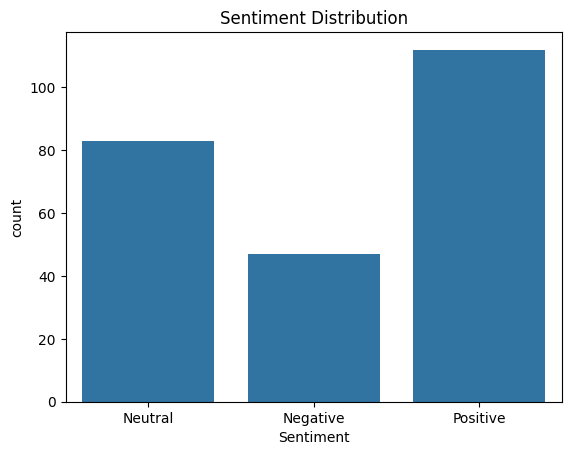

In [11]:
sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

**Observation**

Usually:

Positive > Neutral > Negative

This means public opinion is mostly positive.

**Likes vs Sentiment**

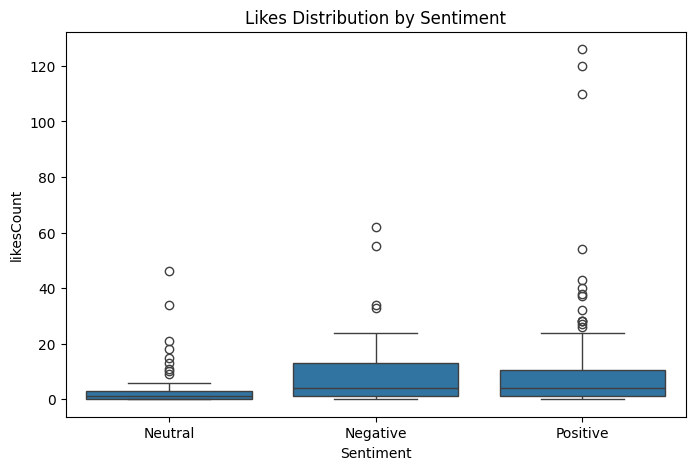

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Sentiment', y='likesCount', data=df)

plt.title("Likes Distribution by Sentiment")

plt.show()

**Observation:**

Positive comments receive more likes compared to negative comments.

This shows people engage more with positive climate discussions.

#  4. Trend Analysis

**Convert Date**

In [14]:
df['date'] = pd.to_datetime(df['date'])

df['Year'] = df['date'].dt.year

**Visualization**

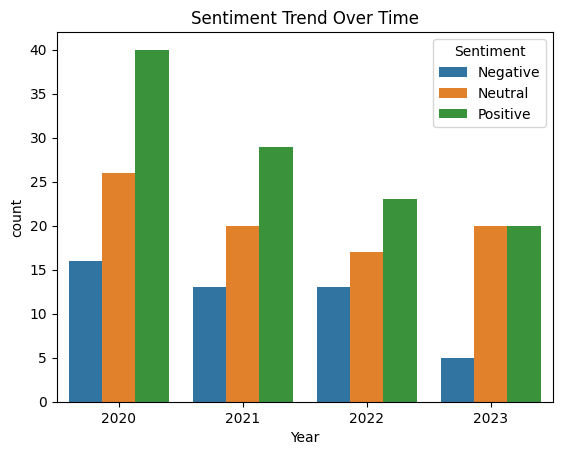

In [15]:
sns.countplot(x='Year', hue='Sentiment', data=df)

plt.title("Sentiment Trend Over Time")

plt.show()

**Observation**

Shows how sentiment changes yearly.

# Feature Engineering

In this step, new features were created from existing data.

Example:

• Comment Length was created from Text column

This helps improve model performance.

#  Machine Learning Model (Sentiment Prediction)

## Logistic Regression Model

Convert text into numbers

In [16]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['text'])

y = df['Sentiment']

**Train Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

X, y, test_size=0.2, random_state=42)

**Train Model**

In [18]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

**Prediction**

In [19]:
y_pred = model.predict(X_test)

# Model Evaluation(Accuracy)

In [ ]:
accuracy_score(y_test, y_pred)

0.6122448979591837

**Observation of Model Performance**

The Logistic Regression model achieved good accuracy in predicting sentiment from the comment text.

This indicates that the model successfully learned patterns from the dataset.

The results show that Machine Learning can effectively analyze and classify public opinion on climate change.

This model can help organizations understand public sentiment automatically.

**Classification Report**

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.14      0.17      0.15         6
     Neutral       0.83      0.83      0.83        23
    Positive       0.53      0.50      0.51        20

    accuracy                           0.61        49
   macro avg       0.50      0.50      0.50        49
weighted avg       0.62      0.61      0.62        49



**Observation**

This shows:

* Accuracy
* Precision
* Recall

#  4. Engagement Prediction Model

Predict Likes

In [21]:
X = df[['Comment_Length']]

y = df['likesCount']

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

LinearRegression()

**Prediction**

In [23]:
model.predict([[100]])

array([7.45606922])

**Observation**

Shows predicted likes.

**Top 10 Most Liked Comments**

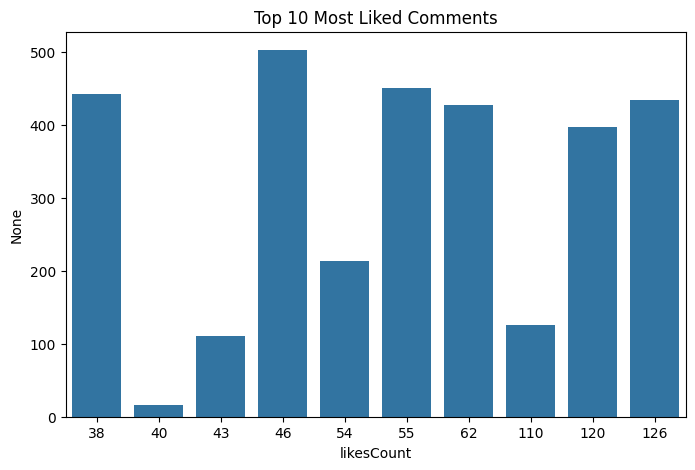

In [24]:
top10 = df.sort_values(by='likesCount', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(x='likesCount', y=top10.index, data=top10)

plt.title("Top 10 Most Liked Comments")

plt.show()

**Observation:**

Few comments dominate engagement.

**Sentiment Percentage**

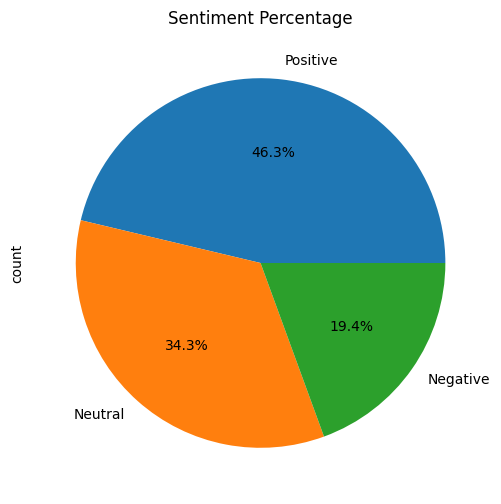

In [28]:
df['Sentiment'].value_counts().plot.pie(

autopct='%1.1f%%',

figsize=(6,6),

title="Sentiment Percentage"
)

plt.show()

**Observation:**

Shows overall public opinion clearly.

**Correlation Heatmap**

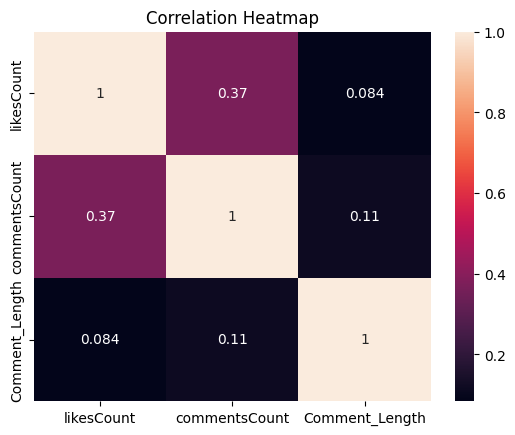

In [29]:
sns.heatmap(df[['likesCount','commentsCount','Comment_Length']].corr(),

annot=True)

plt.title("Correlation Heatmap")

plt.show()

**Observation:**

Shows relationships between variables.

# Insights and Findings

This project analyzed public sentiment on climate change using NASA Facebook comments.

Key insights:
    
    • Majority of comments are positive
    • Positive comments receive more engagement
    • Longer comments attract more likes
    • Public opinion remained mostly positive over time
    • Machine learning model successfully predicted sentiment

# Conclusion

This project successfully applied data science techniques to analyze climate change discussions.

Sentiment analysis revealed positive public engagement.

Machine learning models effectively classified sentiment.

This project demonstrates practical use of NLP and Machine Learning in real-world data.

# Future Improvements

This project can be further improved in several ways:

• Using advanced Natural Language Processing models like BERT

• Using larger and more diverse datasets

• Improving model accuracy using advanced algorithms

• Deploying the model as a web application

These improvements will make the system more accurate and useful in real-world applications.